# Affine alignment: SBERT vs layer-wise LM — train vs test R² (bar plots)

**SBERT (prompt embeddings):** loads `affine_transformation_sbert/<A_forward|B_forward>/*.json` from `affine_transformation_sbert.py`. Each file aggregates **three split RNG seeds** (`split_seed_0` … `split_seed_2`); we plot the **mean** train and test R² with **error bars** (standard deviation across those seeds).

**Layer-wise LM (mean over grid):** loads `affine_transformation/.../combined_metrics_*_allreps.json` for every `(layer A, layer B)` in a 32×32 grid. Bars show the **mean** train and test R² **across layer combinations**; **error bars** = standard deviation **across layer pairs** (spread of R² over the grid).

**Layer-wise LM (best pair):** for each model pair we **argmax** test R² over the 32×32 layer grid and plot train/test at that **single** `(layer A, layer B)`; **error bars** = the reported seed std from that JSON (same convention as the grid-mean plot).

One **group** per **model pair** (four ordered Mistral pairs); each group has two bars: **train R²** and **test R²**.

In [2]:
import os
import sys
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
_repo = None
for candidate in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (candidate / "experiment_config.py").is_file() and (candidate / "utils.py").is_file():
        _repo = candidate
        break
if _repo is None:
    raise FileNotFoundError(
        "Could not find repo root (need experiment_config.py + utils.py)."
    )
sys.path.insert(0, str(_repo))

from utils import REPO_ROOT
from experiment_config import STAGE_A_SEEDS

SBERT_ROOT = os.path.join(REPO_ROOT, "affine_transformation_sbert")
print("REPO_ROOT:", REPO_ROOT)
print("SBERT_ROOT:", SBERT_ROOT)
print("STAGE_A_SEEDS:", STAGE_A_SEEDS)

REPO_ROOT: /juice6/u/jshe/nlp/LM_neural_synchrony
SBERT_ROOT: /juice6/u/jshe/nlp/LM_neural_synchrony/affine_transformation_sbert
STAGE_A_SEEDS: [0]


In [3]:
def pair_label(pair_name: str) -> str:
    """Short label like 'v0.3 → v0.2' from folder name."""
    parts = pair_name.split("_None_0_")
    if len(parts) != 2:
        return pair_name[:32] + "…"
    def ver(chunk: str) -> str:
        m = re.search(r"Instruct-v([0-9.]+)", chunk)
        return m.group(1) if m else chunk
    return f"v{ver(parts[0])} → v{ver(parts[1])}"


def load_sbert_json(path: str) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def train_test_r2_stats(payload: dict) -> tuple:
    """Mean and std of train_r2 and test_r2 over split_seed_* keys."""
    res = payload["results"]
    train_vals = []
    test_vals = []
    for k, v in res.items():
        if not k.startswith("split_seed_"):
            continue
        train_vals.append(float(v["train_r2"]))
        test_vals.append(float(v["test_r2"]))
    tr = np.asarray(train_vals, dtype=np.float64)
    te = np.asarray(test_vals, dtype=np.float64)
    return (
        float(np.mean(tr)),
        float(np.std(tr, ddof=1)) if tr.size > 1 else 0.0,
        float(np.mean(te)),
        float(np.std(te, ddof=1)) if te.size > 1 else 0.0,
        len(tr),
    )


def collect_setting(setting: str) -> list:
    """List of dicts: pair_label, pair_name, train_mean, train_std, test_mean, test_std, path."""
    d = os.path.join(SBERT_ROOT, setting)
    if not os.path.isdir(d):
        print(f"Missing directory: {d}")
        return []
    rows = []
    for name in sorted(os.listdir(d)):
        if not name.endswith(".json"):
            continue
        path = os.path.join(d, name)
        payload = load_sbert_json(path)
        pn = payload["meta"]["pair_name"]
        tm, ts, vm, vs, n = train_test_r2_stats(payload)
        rows.append(
            {
                "pair_label": pair_label(pn),
                "pair_name": pn,
                "train_mean": tm,
                "train_std": ts,
                "test_mean": vm,
                "test_std": vs,
                "n_seeds": n,
                "path": path,
            }
        )
    return rows

In [4]:
rows_a = collect_setting("A_forward")
rows_b = collect_setting("B_forward")
print("A_forward files:", len(rows_a))
for r in rows_a:
    print(
        f"  {r['pair_label']}: train R² = {r['train_mean']:.3f} ± {r['train_std']:.3f}, "
        f"test R² = {r['test_mean']:.3f} ± {r['test_std']:.3f} (n_seeds={r['n_seeds']})"
    )
print("B_forward files:", len(rows_b))
for r in rows_b:
    print(
        f"  {r['pair_label']}: train R² = {r['train_mean']:.3f} ± {r['train_std']:.3f}, "
        f"test R² = {r['test_mean']:.3f} ± {r['test_std']:.3f} (n_seeds={r['n_seeds']})"
    )

A_forward files: 4
  v0.2 → v0.2: train R² = 0.987 ± 0.002, test R² = -0.102 ± 0.350 (n_seeds=3)
  v0.2 → v0.3: train R² = 0.981 ± 0.002, test R² = -0.033 ± 0.195 (n_seeds=3)
  v0.3 → v0.2: train R² = 0.982 ± 0.004, test R² = -0.522 ± 0.973 (n_seeds=3)
  v0.3 → v0.3: train R² = 0.983 ± 0.004, test R² = -0.388 ± 0.914 (n_seeds=3)
B_forward files: 4
  v0.2 → v0.2: train R² = 0.989 ± 0.000, test R² = -0.098 ± 0.418 (n_seeds=3)
  v0.2 → v0.3: train R² = 0.983 ± 0.002, test R² = -0.062 ± 0.043 (n_seeds=3)
  v0.3 → v0.2: train R² = 0.982 ± 0.001, test R² = -0.312 ± 0.412 (n_seeds=3)
  v0.3 → v0.3: train R² = 0.981 ± 0.001, test R² = -0.160 ± 0.514 (n_seeds=3)


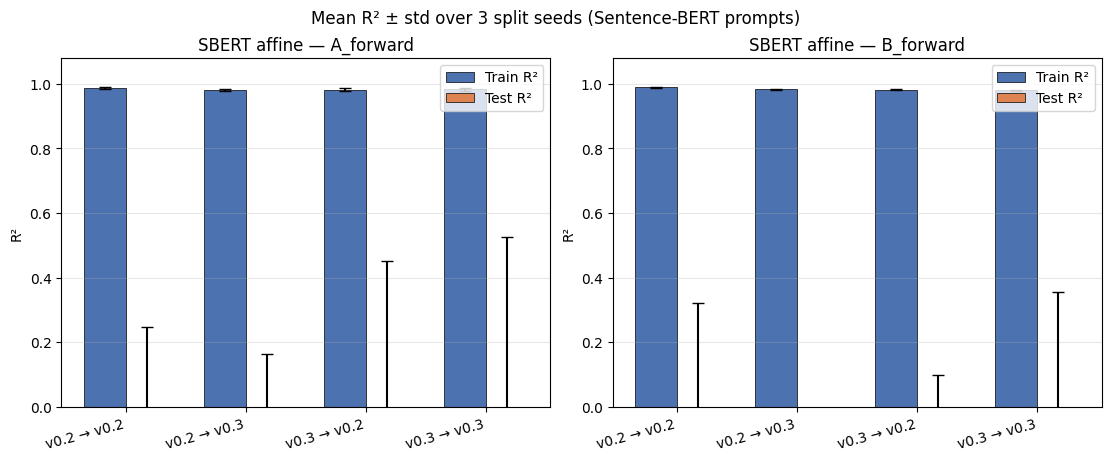

In [5]:
def plot_grouped_bars(rows: list, title: str, ax: plt.Axes):
    if not rows:
        ax.set_visible(False)
        return
    # Stable order: sort by pair_name so plots match across runs
    rows = sorted(rows, key=lambda r: r["pair_name"])
    labels = [r["pair_label"] for r in rows]
    x = np.arange(len(labels))
    w = 0.35
    tr_m = [r["train_mean"] for r in rows]
    tr_e = [r["train_std"] for r in rows]
    te_m = [r["test_mean"] for r in rows]
    te_e = [r["test_std"] for r in rows]

    ax.bar(x - w / 2, tr_m, w, yerr=tr_e, label="Train R²", capsize=4, color="#4C72B0", edgecolor="black", linewidth=0.5)
    ax.bar(x + w / 2, te_m, w, yerr=te_e, label="Test R²", capsize=4, color="#DD8452", edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel("R²")
    hi = max(max(tr_m) + max(tr_e), max(te_m) + max(te_e), 0.15)
    ax.set_ylim(0, min(1.08, hi * 1.15))
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
plot_grouped_bars(rows_a, "SBERT affine — A_forward", axes[0])
plot_grouped_bars(rows_b, "SBERT affine — B_forward", axes[1])
fig.suptitle("Mean R² ± std over 3 split seeds (Sentence-BERT prompts)", fontsize=12)
plt.show()

### Layer-wise LM affine (hidden states)

Loads `affine_transformation/<A_forward|B_forward>/layerA*/data/combined_metrics_*_layerA*_layerB*_allreps.json`. For each model pair, we take **mean test R²** and **mean train R²** over the **evaluation seeds** already stored in each file (`r2_mean[0]`, `train_r2_mean[0]`). **Error bars** = standard deviation **across all layer pairs** (32×32 grid, missing files skipped). Same four Mistral pairs as the SBERT run.

In [6]:
from utils import get_short_names_and_identifiers

AFFINE_ROOT = os.path.join(REPO_ROOT, "affine_transformation")
DATA_MODE = "combined_metrics"
LAYER_RANGE = range(32)  # Mistral-7B: 32 layers (0..31)

MODEL_PAIRS = [
    ("Mistral-7B-Instruct-v0.3", "Mistral-7B-Instruct-v0.3"),
    ("Mistral-7B-Instruct-v0.3", "Mistral-7B-Instruct-v0.2"),
    ("Mistral-7B-Instruct-v0.2", "Mistral-7B-Instruct-v0.3"),
    ("Mistral-7B-Instruct-v0.2", "Mistral-7B-Instruct-v0.2"),
]


def discover_affine_models_id(model_1: str, model_2: str, setting: str) -> str:
    """Match filename suffix on disk (e.g. [0] vs [0, 1, 2, 3, 4])."""
    combined = f"{model_1}_{model_2}"
    _, mid = get_short_names_and_identifiers([combined])
    data_dir = os.path.join(AFFINE_ROOT, setting, "layerA0", "data")
    if not os.path.isdir(data_dir):
        return mid + str(list(STAGE_A_SEEDS))
    import glob

    pat = os.path.join(data_dir, f"{DATA_MODE}_{mid}*_layerA0_layerB0_allreps.json")
    matches = glob.glob(pat)
    if not matches:
        return mid + str(list(STAGE_A_SEEDS))
    fname = os.path.basename(matches[0])
    prefix = f"{DATA_MODE}_"
    rest = fname[len(prefix) :]
    return rest.split("_layerA")[0]


def pair_name_from_models(model_1: str, model_2: str) -> str:
    return f"{model_1}_None_0_{model_2}_None_0"


def collect_layer_affine_rows(setting: str) -> list:
    """One row per model pair: mean/std of train & test R² across all layer combinations."""
    rows_out = []
    for model_1, model_2 in MODEL_PAIRS:
        combined = f"{model_1}_{model_2}"
        short_names, _ = get_short_names_and_identifiers([combined])
        key = short_names[0]
        models_id = discover_affine_models_id(model_1, model_2, setting)
        train_vals = []
        test_vals = []
        for la in LAYER_RANGE:
            for lb in LAYER_RANGE:
                fname = f"{DATA_MODE}_{models_id}_layerA{la}_layerB{lb}_allreps.json"
                p = os.path.join(AFFINE_ROOT, setting, f"layerA{la}", "data", fname)
                if not os.path.isfile(p):
                    continue
                with open(p, "r", encoding="utf-8") as f:
                    data = json.load(f)
                if key not in data:
                    continue
                d = data[key]
                test_vals.append(float(d["r2_mean"][0]))
                train_vals.append(float(d["train_r2_mean"][0]))
        if not test_vals:
            print(f"WARN: no layer files for {setting} / {combined}")
            continue
        tr = np.asarray(train_vals, dtype=np.float64)
        te = np.asarray(test_vals, dtype=np.float64)
        pn = pair_name_from_models(model_1, model_2)
        rows_out.append(
            {
                "pair_label": pair_label(pn),
                "pair_name": pn,
                "train_mean": float(np.mean(tr)),
                "train_std": float(np.std(tr, ddof=1)) if tr.size > 1 else 0.0,
                "test_mean": float(np.mean(te)),
                "test_std": float(np.std(te, ddof=1)) if te.size > 1 else 0.0,
                "n_layer_pairs": len(test_vals),
            }
        )
    return rows_out


layer_rows_a = collect_layer_affine_rows("A_forward")
layer_rows_b = collect_layer_affine_rows("B_forward")
print("Layer LM — A_forward:", len(layer_rows_a), "pairs")
for r in layer_rows_a:
    print(
        f"  {r['pair_label']}: train {r['train_mean']:.4f} ± {r['train_std']:.4f}, "
        f"test {r['test_mean']:.4f} ± {r['test_std']:.4f} (n={r['n_layer_pairs']} layer pairs)"
    )
print("Layer LM — B_forward:", len(layer_rows_b), "pairs")
for r in layer_rows_b:
    print(
        f"  {r['pair_label']}: train {r['train_mean']:.4f} ± {r['train_std']:.4f}, "
        f"test {r['test_mean']:.4f} ± {r['test_std']:.4f} (n={r['n_layer_pairs']} layer pairs)"
    )

Layer LM — A_forward: 4 pairs
  v0.3 → v0.3: train 0.8392 ± 0.2363, test 0.1862 ± 0.1549 (n=1024 layer pairs)
  v0.3 → v0.2: train 0.8266 ± 0.2510, test 0.0961 ± 0.1740 (n=1024 layer pairs)
  v0.2 → v0.3: train 0.8356 ± 0.2490, test 0.1164 ± 0.1778 (n=1024 layer pairs)
  v0.2 → v0.2: train 0.8360 ± 0.2463, test -0.0102 ± 0.2216 (n=1024 layer pairs)
Layer LM — B_forward: 4 pairs
  v0.3 → v0.3: train 0.8458 ± 0.2419, test 0.1759 ± 0.1423 (n=1024 layer pairs)
  v0.3 → v0.2: train 0.8418 ± 0.2518, test 0.0982 ± 0.1487 (n=1024 layer pairs)
  v0.2 → v0.3: train 0.8239 ± 0.2605, test 0.0036 ± 0.1686 (n=1024 layer pairs)
  v0.2 → v0.2: train 0.8468 ± 0.2462, test 0.0816 ± 0.1386 (n=1024 layer pairs)


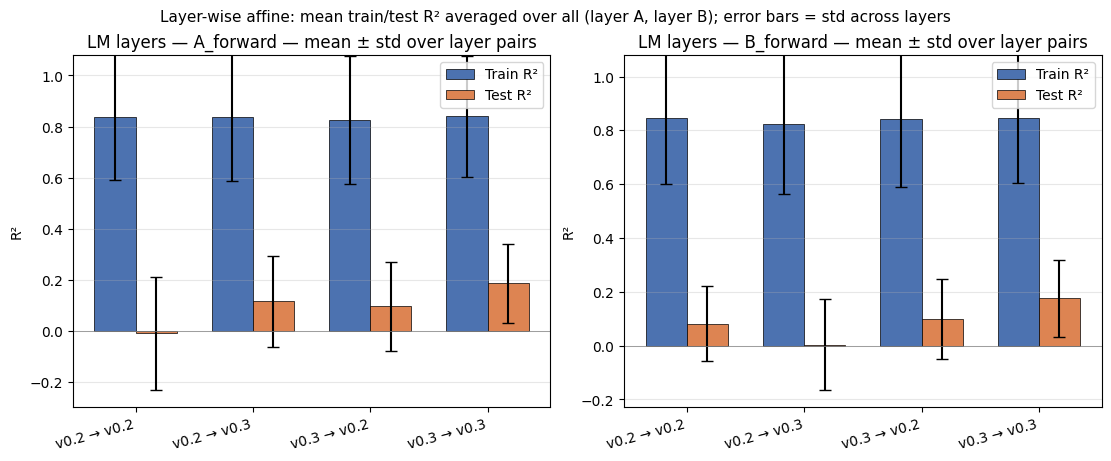

In [7]:
def plot_grouped_bars_layer(rows: list, title: str, ax: plt.Axes, subtitle: str = ""):
    """Grouped train/test bars; y-limits allow negative R² when needed."""
    if not rows:
        ax.set_visible(False)
        return
    rows = sorted(rows, key=lambda r: r["pair_name"])
    labels = [r["pair_label"] for r in rows]
    x = np.arange(len(labels))
    w = 0.35
    tr_m = np.array([r["train_mean"] for r in rows], dtype=float)
    tr_e = np.array([r["train_std"] for r in rows], dtype=float)
    te_m = np.array([r["test_mean"] for r in rows], dtype=float)
    te_e = np.array([r["test_std"] for r in rows], dtype=float)

    ax.bar(
        x - w / 2,
        tr_m,
        w,
        yerr=tr_e,
        label="Train R²",
        capsize=4,
        color="#4C72B0",
        edgecolor="black",
        linewidth=0.5,
    )
    ax.bar(
        x + w / 2,
        te_m,
        w,
        yerr=te_e,
        label="Test R²",
        capsize=4,
        color="#DD8452",
        edgecolor="black",
        linewidth=0.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel("R²")
    lo = min(0, np.min(tr_m - tr_e), np.min(te_m - te_e))
    hi = max(np.max(tr_m + tr_e), np.max(te_m + te_e), 0.05)
    pad_lo = lo - 0.05 * (hi - lo) if lo < 0 else 0
    pad_hi = hi + 0.05 * (hi - lo)
    ax.set_ylim(pad_lo, min(1.08, pad_hi))
    ax.set_title(title + (f" — {subtitle}" if subtitle else ""))
    ax.legend(loc="upper right")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)


fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
plot_grouped_bars_layer(layer_rows_a, "LM layers — A_forward", axes2[0], "mean ± std over layer pairs")
plot_grouped_bars_layer(layer_rows_b, "LM layers — B_forward", axes2[1], "mean ± std over layer pairs")
fig2.suptitle(
    "Layer-wise affine: mean train/test R² averaged over all (layer A, layer B); error bars = std across layers",
    fontsize=11,
)
plt.show()

### Layer–layer LM affine: bidirectional SyncR² (clamped)

Each JSON cell `(layer A = i, layer B = j)` reports **test** / **train** R² for the affine map that predicts **agent B’s** hidden state at layer **j** from **agent A’s** state at layer **i** (same convention as `affine_transformation.py`).

**Clamp:** negative R² is set to **0** (worse than predicting the mean ⇒ no synchrony).

**SyncR²(A→B):** for each **source layer** index **i** in A, choose **j** that maximizes **clipped test R²** in that row; then average those best-case **clipped** train/test values over all **i** (rows with at least one valid pair).

**SyncR²(B→A) (transpose on the same grid):** for each **target layer** index **j** in B, choose **i** that maximizes **clipped test R²** in that column; average over **j**.

**Bidirectional score:** **mean** of SyncR²(A→B) and SyncR²(B→A) for **train** and **test** separately. **Error bars** ≈ average of the two directional standard deviations (spread **across** source layers in each direction); not the JSON seed std.

Bidirectional SyncR² (clipped) — A_forward:
  v0.3 → v0.3: bidir train 0.8450 ± 0.1394, test 0.3529 ± 0.1398
    A→B: train 0.8755, test 0.3724 (n_A=32); B→A: train 0.8146, test 0.3333 (n_B=32)
  v0.3 → v0.2: bidir train 0.8239 ± 0.1516, test 0.2743 ± 0.1392
    A→B: train 0.8568, test 0.3086 (n_A=32); B→A: train 0.7910, test 0.2400 (n_B=32)
  v0.2 → v0.3: bidir train 0.7858 ± 0.1663, test 0.2970 ± 0.1311
    A→B: train 0.8696, test 0.3250 (n_A=32); B→A: train 0.7019, test 0.2690 (n_B=32)
  v0.2 → v0.2: bidir train 0.7773 ± 0.2232, test 0.2169 ± 0.1622
    A→B: train 0.8634, test 0.2242 (n_A=32); B→A: train 0.6912, test 0.2096 (n_B=32)
Bidirectional SyncR² (clipped) — B_forward:
  v0.3 → v0.3: bidir train 0.8545 ± 0.1396, test 0.3289 ± 0.1361
    A→B: train 0.8773, test 0.3589 (n_A=32); B→A: train 0.8318, test 0.2989 (n_B=32)
  v0.3 → v0.2: bidir train 0.8242 ± 0.1643, test 0.2552 ± 0.1243
    A→B: train 0.8665, test 0.2502 (n_A=32); B→A: train 0.7819, test 0.2602 (n_B=32)
  v0.2 → v0.

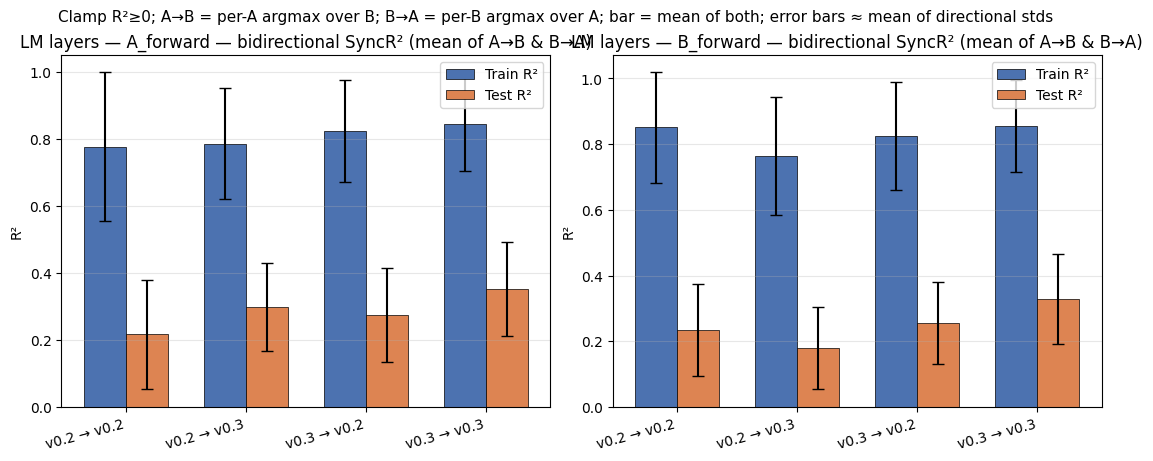

In [12]:
def clip_r2_nonnegative(x: float) -> float:
    return max(0.0, float(x))


def collect_bidirectional_sync_r2_rows(setting: str) -> list:
    """SyncR²(A→B) + SyncR²(B→A) on same grid; argmax on clipped test R²; bidirectional = mean of directions."""
    nL = len(LAYER_RANGE)
    rows_out = []
    for model_1, model_2 in MODEL_PAIRS:
        combined = f"{model_1}_{model_2}"
        short_names, _ = get_short_names_and_identifiers([combined])
        key = short_names[0]
        models_id = discover_affine_models_id(model_1, model_2, setting)
        te_g = np.full((nL, nL), np.nan, dtype=np.float64)
        tr_g = np.full((nL, nL), np.nan, dtype=np.float64)
        for la in LAYER_RANGE:
            for lb in LAYER_RANGE:
                fname = f"{DATA_MODE}_{models_id}_layerA{la}_layerB{lb}_allreps.json"
                p = os.path.join(AFFINE_ROOT, setting, f"layerA{la}", "data", fname)
                if not os.path.isfile(p):
                    continue
                with open(p, "r", encoding="utf-8") as f:
                    data = json.load(f)
                if key not in data:
                    continue
                d = data[key]
                te_g[la, lb] = clip_r2_nonnegative(d["r2_mean"][0])
                tr_g[la, lb] = clip_r2_nonnegative(d["train_r2_mean"][0])

        tr_ab, te_ab = [], []
        for la in LAYER_RANGE:
            row = te_g[la, :]
            if np.all(np.isnan(row)):
                continue
            lb_star = int(np.nanargmax(row))
            te_ab.append(te_g[la, lb_star])
            tr_ab.append(tr_g[la, lb_star])
        tr_ba, te_ba = [], []
        for lb in LAYER_RANGE:
            col = te_g[:, lb]
            if np.all(np.isnan(col)):
                continue
            la_star = int(np.nanargmax(col))
            te_ba.append(te_g[la_star, lb])
            tr_ba.append(tr_g[la_star, lb])

        if not te_ab or not te_ba:
            print(f"WARN: incomplete grid for {setting} / {combined} (AB={len(te_ab)}, BA={len(te_ba)})")
            continue

        tr_ab, te_ab = np.asarray(tr_ab), np.asarray(te_ab)
        tr_ba, te_ba = np.asarray(tr_ba), np.asarray(te_ba)
        std_tr_ab = float(np.std(tr_ab, ddof=1)) if tr_ab.size > 1 else 0.0
        std_te_ab = float(np.std(te_ab, ddof=1)) if te_ab.size > 1 else 0.0
        std_tr_ba = float(np.std(tr_ba, ddof=1)) if tr_ba.size > 1 else 0.0
        std_te_ba = float(np.std(te_ba, ddof=1)) if te_ba.size > 1 else 0.0

        pn = pair_name_from_models(model_1, model_2)
        rows_out.append(
            {
                "pair_label": pair_label(pn),
                "pair_name": pn,
                "train_mean": 0.5 * (float(np.mean(tr_ab)) + float(np.mean(tr_ba))),
                "train_std": 0.5 * (std_tr_ab + std_tr_ba),
                "test_mean": 0.5 * (float(np.mean(te_ab)) + float(np.mean(te_ba))),
                "test_std": 0.5 * (std_te_ab + std_te_ba),
                "mean_train_ab": float(np.mean(tr_ab)),
                "mean_test_ab": float(np.mean(te_ab)),
                "mean_train_ba": float(np.mean(tr_ba)),
                "mean_test_ba": float(np.mean(te_ba)),
                "n_layers_a": int(te_ab.size),
                "n_layers_b": int(te_ba.size),
            }
        )
    return rows_out


sync_bidir_rows_a = collect_bidirectional_sync_r2_rows("A_forward")
sync_bidir_rows_b = collect_bidirectional_sync_r2_rows("B_forward")
print("Bidirectional SyncR² (clipped) — A_forward:")
for r in sync_bidir_rows_a:
    print(
        f"  {r['pair_label']}: bidir train {r['train_mean']:.4f} ± {r['train_std']:.4f}, "
        f"test {r['test_mean']:.4f} ± {r['test_std']:.4f}\n"
        f"    A→B: train {r['mean_train_ab']:.4f}, test {r['mean_test_ab']:.4f} (n_A={r['n_layers_a']}); "
        f"B→A: train {r['mean_train_ba']:.4f}, test {r['mean_test_ba']:.4f} (n_B={r['n_layers_b']})"
    )
print("Bidirectional SyncR² (clipped) — B_forward:")
for r in sync_bidir_rows_b:
    print(
        f"  {r['pair_label']}: bidir train {r['train_mean']:.4f} ± {r['train_std']:.4f}, "
        f"test {r['test_mean']:.4f} ± {r['test_std']:.4f}\n"
        f"    A→B: train {r['mean_train_ab']:.4f}, test {r['mean_test_ab']:.4f} (n_A={r['n_layers_a']}); "
        f"B→A: train {r['mean_train_ba']:.4f}, test {r['mean_test_ba']:.4f} (n_B={r['n_layers_b']})"
    )

fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
plot_grouped_bars_layer(sync_bidir_rows_a, "LM layers — A_forward", axes3[0], "bidirectional SyncR² (mean of A→B & B→A)")
plot_grouped_bars_layer(sync_bidir_rows_b, "LM layers — B_forward", axes3[1], "bidirectional SyncR² (mean of A→B & B→A)")
fig3.suptitle(
    "Clamp R²≥0; A→B = per-A argmax over B; B→A = per-B argmax over A; bar = mean of both; error bars ≈ mean of directional stds",
    fontsize=11,
)
plt.show()